In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Exploratory Data Analysis

## 1.  General Secondary Education in Ukraine 2024/2025 
#### Selected excel sheets:

1. Number of general secondary educational institutions at the beginning of 2024/25 academic year by region - 6
2. Number of general secondary educational institutions in urban areas at the beginning of 2024/25 academic year by region - 11
3. Number of general secondary educational institutions in rural areas at the beginning of 2024/25 academic year by region - 12
4. Number of pupils and teachers per general secondary educational institution at the beginning of 2024/25 academic year by regions - 18
5. Number of pupils in general secondary educational institutions at the beginning of 2024/25 academic year by region - 19
6. Number of pupils in general secondary educational institutions in urban areas  at the beginning of 2024/25 academic year by region - 20
7. Number of pupils in general secondary educational institutions in rural areas at the beginning of 2024/25 academic year by region - 21
8. Organization of transportation of children to school at the beginning of 2024/25 academic year by region - 56

In [12]:
FILE = 'data/derzhstat2024_secondary_education.xlsx'
DASH = '\u2212'  # U+2212 — the statistical minus sign used for missing/zero values

def clean_df(df):
    """Replace the statistical dash (−) with NaN and reset index."""
    return df.replace(DASH, np.nan).reset_index(drop=True)

def read_simple(sheet, start_row, col_names):
    """Read sheets with a single flat table (sheets 6, 18, 56)."""
    df = pd.read_excel(FILE, sheet_name=sheet, header=None)
    df = df.iloc[start_row:].dropna(subset=[0])
    df.columns = col_names
    return clean_df(df)

def read_split(sheet, start_row, left_cols, right_cols):
    """
    Read wide sheets that are physically split across 16 columns (sheets 11, 12, 19, 20, 21).
    Left half  = cols 0–7  (region_ua | data cols | region_en)
    Right half = cols 8–15 (region_ua | data cols | region_en)  ← continuation
    """
    df = pd.read_excel(FILE, sheet_name=sheet, header=None)
    df = df.iloc[start_row:].dropna(subset=[0])
    left  = df.iloc[:, :8].copy()
    right = df.iloc[:, 8:].copy()
    right.columns = range(8)
    left.columns  = left_cols
    right.columns = right_cols
    right = right.drop(columns=['region_ua_r', 'region_en_r'])
    return clean_df(pd.concat([left, right], axis=1))


# ── Sheet 6 ──────────────────────────────────────────────────────────────────
# Number of institutions (all areas), simple 11-col layout, data starts row 8
df6 = read_simple(
    sheet='6', start_row=8,
    col_names=[
        'region_ua',
        'total_institutions',
        'total_pupils', 'total_teachers',
        'public_institutions',
        'public_pupils', 'public_teachers',
        'private_institutions',
        'private_pupils', 'private_teachers',
        'region_en',
    ]
)

# ── Sheets 11 & 12 ───────────────────────────────────────────────────────────
# Institutions by type, urban / rural — wide/split 16-col layout, data starts row 8
_inst_left  = ['region_ua', 'total',
               'primary_w_preschool', 'primary',
               'gymnasium_w_preschool_primary', 'gymnasium_w_primary', 'gymnasium',
               'region_en']
_inst_right = ['region_ua_r',
               'lyceum_w_preschool_primary_gymnasium', 'lyceum_w_primary_gymnasium',
               'lyceum_w_preschool_gymnasium', 'lyceum_w_gymnasium', 'lyceum',
               'special', 'region_en_r']

df11 = read_split('11', start_row=8, left_cols=_inst_left,   right_cols=_inst_right)  # urban
df12 = read_split('12', start_row=8, left_cols=_inst_left,   right_cols=_inst_right)  # rural

# ── Sheet 18 ─────────────────────────────────────────────────────────────────
# Pupils & teachers per institution, simple 8-col layout, data starts row 6
df18 = read_simple(
    sheet='18', start_row=6,
    col_names=[
        'region_ua',
        'pupils_per_inst_all',     'teachers_per_inst_all',
        'pupils_per_inst_public',  'teachers_per_inst_public',
        'pupils_per_inst_private', 'teachers_per_inst_private',
        'region_en',
    ]
)

# ── Sheets 19, 20, 21 ────────────────────────────────────────────────────────
# Pupil counts by institution type (all / urban / rural) — same split layout, data starts row 8
_pupils_left  = ['region_ua', 'total',
                 'primary_w_preschool', 'primary',
                 'gymnasium_w_preschool_primary', 'gymnasium_w_primary', 'gymnasium',
                 'region_en']
_pupils_right = ['region_ua_r',
                 'lyceum_w_preschool_primary_gymnasium', 'lyceum_w_primary_gymnasium',
                 'lyceum_w_preschool_gymnasium', 'lyceum_w_gymnasium', 'lyceum',
                 'special', 'region_en_r']

df19 = read_split('19', start_row=8, left_cols=_pupils_left, right_cols=_pupils_right)  # all
df20 = read_split('20', start_row=8, left_cols=_pupils_left, right_cols=_pupils_right)  # urban
df21 = read_split('21', start_row=8, left_cols=_pupils_left, right_cols=_pupils_right)  # rural

# ── Sheet 56 ─────────────────────────────────────────────────────────────────
# Transportation, simple 8-col layout, data starts row 6
df56 = read_simple(
    sheet='56', start_row=6,
    col_names=[
        'region_ua',
        'urban_rural_need_transport', 'urban_rural_transport_organized', 'urban_rural_school_bus',
        'rural_need_transport',       'rural_transport_organized',       'rural_school_bus',
        'region_en',
    ]
)

In [13]:
dfs = [df6, df11, df12, df18, df19, df20, df21, df56]

In [14]:
for df in dfs:
    print(df.head())

          region_ua total_institutions total_pupils total_teachers  \
0           Україна              12291      3743887         380877   
1         Вінницька                602       158670          17984   
2         Волинська                518       137331          16611   
3  Дніпропетровська                820       308580          25788   
4          Донецька                256        76768           7051   

  public_institutions public_pupils public_teachers private_institutions  \
0               11781       3646129          369850                  510   
1                 590        157120           17641                   12   
2                 513        136776           16509                    5   
3                 797        306467           25439                   23   
4                 255         76694            7040                    1   

  private_pupils private_teachers       region_en  
0          97758            11027         Ukraine  
1           1550  

In [15]:
for df in dfs:
    print(df.columns)

Index(['region_ua', 'total_institutions', 'total_pupils', 'total_teachers',
       'public_institutions', 'public_pupils', 'public_teachers',
       'private_institutions', 'private_pupils', 'private_teachers',
       'region_en'],
      dtype='str')
Index(['region_ua', 'total', 'primary_w_preschool', 'primary',
       'gymnasium_w_preschool_primary', 'gymnasium_w_primary', 'gymnasium',
       'region_en', 'lyceum_w_preschool_primary_gymnasium',
       'lyceum_w_primary_gymnasium', 'lyceum_w_preschool_gymnasium',
       'lyceum_w_gymnasium', 'lyceum', 'special'],
      dtype='str')
Index(['region_ua', 'total', 'primary_w_preschool', 'primary',
       'gymnasium_w_preschool_primary', 'gymnasium_w_primary', 'gymnasium',
       'region_en', 'lyceum_w_preschool_primary_gymnasium',
       'lyceum_w_primary_gymnasium', 'lyceum_w_preschool_gymnasium',
       'lyceum_w_gymnasium', 'lyceum', 'special'],
      dtype='str')
Index(['region_ua', 'pupils_per_inst_all', 'teachers_per_inst_all',
     

#### National snapshot & regional institution counts
Sheet 6 gives us the cleanest high-level view: total institutions broken down by public vs private ownership, with pupil and teacher totals.

In [6]:
nat = df6[df6['region_ua'] == 'Україна'].iloc[0]
print(nat[['total_institutions','total_pupils','total_teachers',
          'public_institutions','private_institutions']])

total_institutions        12291
total_pupils            3743887
total_teachers           380877
public_institutions       11781
private_institutions        510
Name: 0, dtype: object


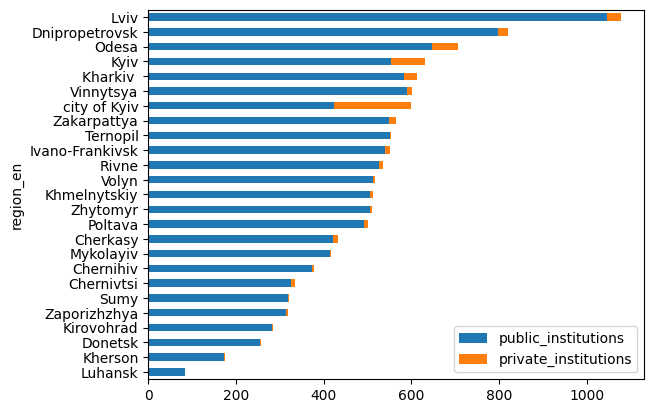

In [7]:
reg6 = df6[(df6['region_ua'] != 'Україна') & (df6['region_en'].notna())].copy()
reg6 = reg6.sort_values('total_institutions')
reg6['private_share'] = reg6['private_institutions'] / reg6['total_institutions'] * 100
ax = reg6.plot.barh(x='region_en', y=['public_institutions','private_institutions'], stacked=True)


Lviv (1,077) and Dnipro (820) oblasts lead in raw institution count. War-exposed oblasts (Donetsk 256, Luhansk 83, Kherson 174) sit at the bottom, reflecting both pre-war geography and wartime closures.

City of Kyiv has the highest private school density: 177 private out of 600 total =
29.5%
Second is Kyiv oblast at 12%. All other regions stay below 9%.
hypothesis

(brain drain of best teachers/pupils) is structurally plausible: private schools concentrate heavily in Kyiv where international mobility is highest.

#### Urban–rural institution type mix & school size

Sheets 11 (urban) and 12 (rural) break institutions down by type: primary schools, gymnasiums, lyceums, and special schools

In [8]:
C_BLUE   = '#58a6ff'
C_AMBER  = '#d29922'
C_GREEN  = '#3fb950'
C_RED    = '#f85149'
C_PURPLE = '#bc8cff'
C_ORANGE = '#ffa657'

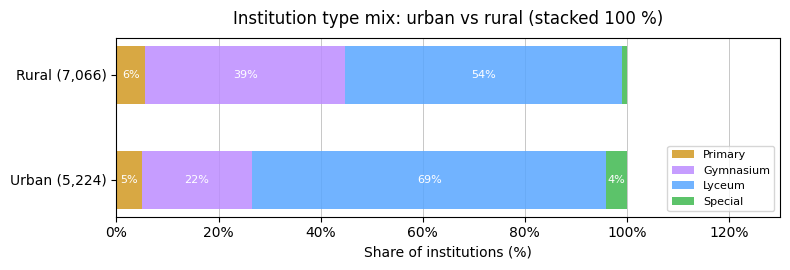

In [9]:
def fig_2_1(df11, df12):
    # Aggregate columns that belong to each broad type
    # The split sheets have these institution-type columns:
    #   primary_w_preschool, primary
    #   gymnasium_w_preschool_primary, gymnasium_w_primary, gymnasium
    #   lyceum_w_preschool_primary_gymnasium, lyceum_w_primary_gymnasium,
    #   lyceum_w_preschool_gymnasium, lyceum_w_gymnasium, lyceum
    #   special
 
    def national_totals(df):
        # take the row that has no region_en (national summary)
        nat = df[df['region_ua'] == 'Україна'].copy()
        if nat.empty:
            nat = df[df['region_en'].isna()].head(1).copy()
        num_cols = [c for c in df.columns if c not in ('region_ua', 'region_en', 'region_ua_r', 'region_en_r')]
        for c in num_cols:
            nat[c] = pd.to_numeric(nat[c], errors='coerce')
        return nat.iloc[0]
 
    u = national_totals(df11)
    r = national_totals(df12)
 
    primary_cols   = ['primary_w_preschool', 'primary']
    gymn_cols      = ['gymnasium_w_preschool_primary', 'gymnasium_w_primary', 'gymnasium']
    lyceum_cols    = ['lyceum_w_preschool_primary_gymnasium', 'lyceum_w_primary_gymnasium',
                      'lyceum_w_preschool_gymnasium', 'lyceum_w_gymnasium', 'lyceum']
    special_cols   = ['special']
 
    def safe_sum(row, cols):
        return sum(pd.to_numeric(row.get(c, 0), errors='coerce') or 0 for c in cols)
 
    groups = {
        'Primary':   (safe_sum(u, primary_cols),  safe_sum(r, primary_cols)),
        'Gymnasium': (safe_sum(u, gymn_cols),     safe_sum(r, gymn_cols)),
        'Lyceum':    (safe_sum(u, lyceum_cols),   safe_sum(r, lyceum_cols)),
        'Special':   (safe_sum(u, special_cols),  safe_sum(r, special_cols)),
    }
 
    u_total = sum(v[0] for v in groups.values())
    r_total = sum(v[1] for v in groups.values())
 
    type_colors = [C_AMBER, C_PURPLE, C_BLUE, C_GREEN]
    labels = list(groups.keys())
    u_pcts = [groups[l][0] / u_total * 100 for l in labels]
    r_pcts = [groups[l][1] / r_total * 100 for l in labels]
 
    fig, ax = plt.subplots(figsize=(8, 2.8))
    rows = [f'Urban ({int(u_total):,})', f'Rural ({int(r_total):,})']
    lefts = [0, 0]
    for i, lbl in enumerate(labels):
        vals = [u_pcts[i], r_pcts[i]]
        bars = ax.barh(rows, vals, left=lefts, color=type_colors[i], alpha=0.85,
                       label=lbl, height=0.55)
        for bar, val, raw_u, raw_r in zip(
                bars, vals,
                [groups[lbl][0], groups[lbl][0]],
                [groups[lbl][1], groups[lbl][1]]):
            if val > 4:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f'{val:.0f}%', ha='center', va='center',
                        fontsize=8, color='white')
        lefts = [lefts[j] + vals[j] for j in range(2)]
 
    ax.set_xlim(0, 130)
    ax.set_xlabel('Share of institutions (%)')
    ax.set_title('Institution type mix: urban vs rural (stacked 100 %)', pad=10)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.xaxis.grid(True, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc='lower right', fontsize=8)
    fig.tight_layout()

fig_2_1(df11, df12)

Urban schools are dominated by lyceums (69% of 5,225). Rural schools show a more balanced split: lyceums 54%, gymnasiums 39%, primary 6%. The primary school share is 1.2x higher in rural areas.

Rural areas still have meaningful lyceum presence (54%), but 3,830 rural lyceums serve far fewer pupils per school — average rural school size is ~150 pupils vs ~510 urban. This means rural pupils effectively have thinner upper-secondary provision per capita.

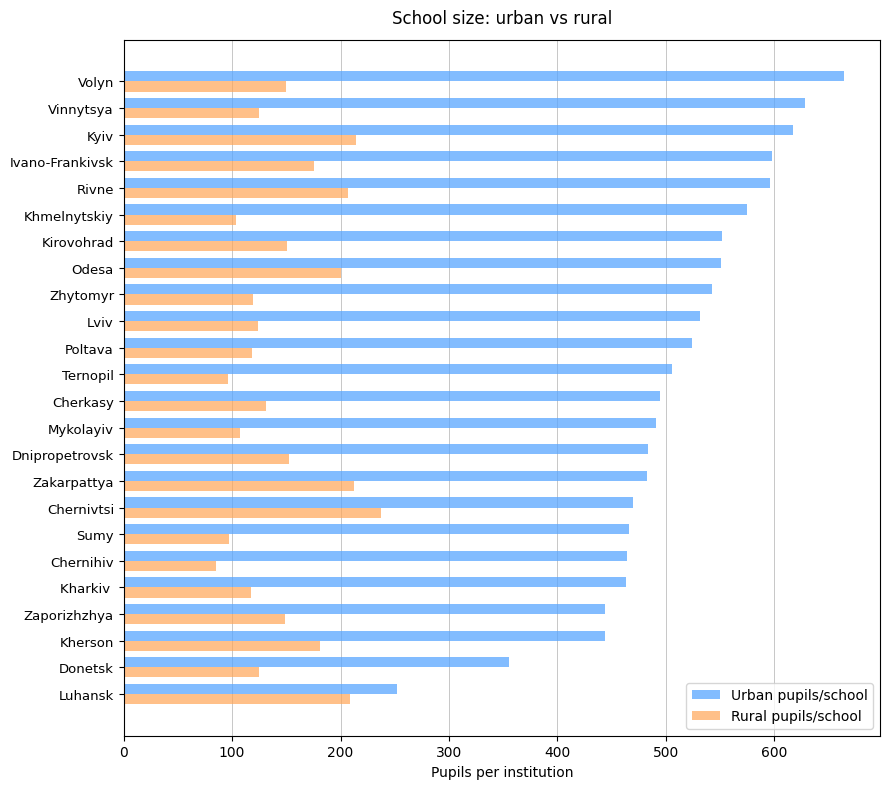

In [10]:
def fig_2_2(df11, df12, df20, df21):
    def region_totals(df, col_alias):
        sub = df[df['region_en'].notna() & (df['region_ua'] != 'Україна')].copy()
        sub['total'] = pd.to_numeric(sub['total'], errors='coerce')
        return sub[['region_en', 'total']].rename(columns={'total': col_alias})
 
    inst_u = region_totals(df11, 'inst_urban')
    inst_r = region_totals(df12, 'inst_rural')
    pup_u  = region_totals(df20, 'pup_urban')
    pup_r  = region_totals(df21, 'pup_rural')
 
    merged = inst_u.merge(inst_r, on='region_en') \
                   .merge(pup_u,  on='region_en') \
                   .merge(pup_r,  on='region_en')
 
    merged['urban'] = merged['pup_urban'] / merged['inst_urban']
    merged['rural'] = merged['pup_rural'] / merged['inst_rural']
    merged = merged.sort_values('urban').dropna(subset=['urban', 'rural'])
 
    fig, ax = plt.subplots(figsize=(9, 8))
    y  = np.arange(len(merged))
    bw = 0.38
 
    ax.barh(y + bw/2, merged['urban'], bw, color=C_BLUE,  alpha=0.75, label='Urban pupils/school')
    ax.barh(y - bw/2, merged['rural'], bw, color=C_ORANGE, alpha=0.70, label='Rural pupils/school')
 
    ax.set_yticks(y)
    ax.set_yticklabels(merged['region_en'], fontsize=9.5)
    ax.set_xlabel('Pupils per institution')
    ax.set_title('School size: urban vs rural', pad=12)
    ax.xaxis.grid(True, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend()
    fig.tight_layout()
fig_2_2(df11, df12, df20, df21)

---